### **Isolation Forest**

DIGITAL

In [ ]:
import pandas as pd

# Load the dataset
df=pd.read_excel("/content/Transformed_dataset_own.xlsx", sheet_name="Sheet2 (Karish digital)")
null_rows = df[df["Date"].isnull() | df["Amount"].isnull() | df["Category"].isnull()]
print(null_rows[["Date", "Amount","Category"]])


Empty DataFrame
Columns: [Date, Amount, Category]
Index: []


In [ ]:
new_df = df[df["Money flow"]=="Expense"][["Date","Amount","Category"]]
print(df["Category"].unique())
new_df = new_df.reset_index(drop=True)
print(new_df)

['Fam' 'Transportation' 'Food' 'Petrol' 'Gifts' 'Health' 'Fruits'
 'Haircare' 'Changing' 'Stationery' 'Food ' 'Outing' 'Recharge' 'Clothes'
 'Movie' 'Trip' 'Essentials']
          Date  Amount        Category
0   2024-08-05      70  Transportation
1   2024-08-06      20            Food
2   2024-08-09      10            Food
3   2024-08-10     200          Petrol
4   2024-08-11     150  Transportation
..         ...     ...             ...
118 2025-01-31     110  Transportation
119 2025-02-03      90  Transportation
120 2025-02-03      20  Transportation
121 2025-02-03     100          Petrol
122 2025-02-04     100            Food

[123 rows x 3 columns]


In [ ]:
result = new_df[new_df['Amount'] > 700][['Category', 'Amount']]
print(result)


     Category  Amount
75    Clothes    1600
79   Changing    1000
99       Trip    1000
102  Changing    1000


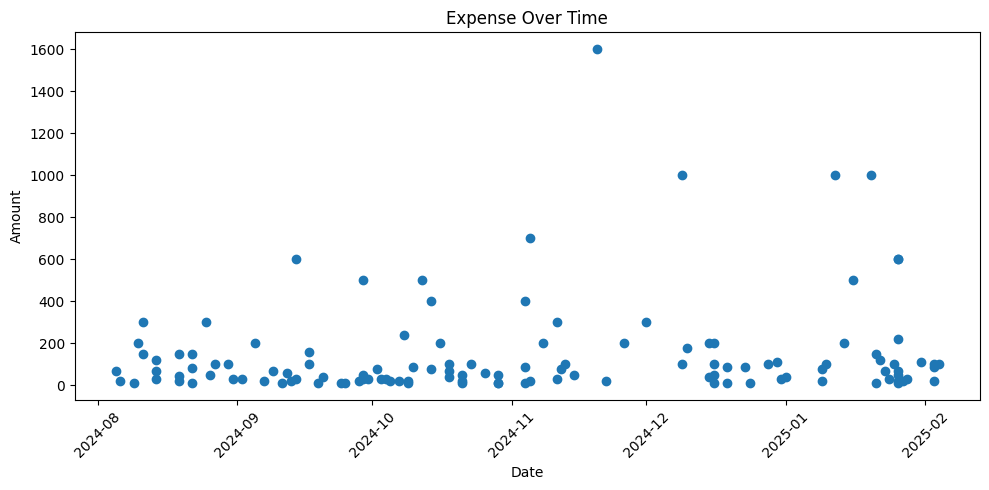

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Date' is in datetime format
new_df['Date'] = pd.to_datetime(new_df['Date'])

# Sort by Date
new_df = new_df.sort_values('Date')

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(new_df['Date'], new_df['Amount'], marker='o', linestyle='-')
plt.title('Expense Over Time')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


WRITTEN

In [ ]:
df1 = pd.read_excel("/content/Transformed_dataset_own_12.xlsx", sheet_name = "Sheet2")
null_rows1 = df1[df1["Date"].isnull() | df1["Amount"].isnull() | df1["Category"].isnull()]
print(null_rows1[["Date", "Amount","Category"]])

Empty DataFrame
Columns: [Date, Amount, Category]
Index: []


In [ ]:
new_df1 = df1[df1["Money flow"]=="Expense"][["Date","Amount","Category"]]
print(df1["Category"].unique())
new_df1 = new_df1.reset_index(drop=True)
print(new_df1)

['Fam' 'Education' 'Food' 'Transportation' 'Stationery' 'Changing'
 'Accessories' 'Gifts' 'Health' 'Cosmetics']
         Date  Amount        Category
0  2023-11-18     450       Education
1  2023-11-22      60            Food
2  2023-11-25     200  Transportation
3  2023-11-28     200  Transportation
4  2023-12-02     120            Food
..        ...     ...             ...
86 2024-11-21     250            Food
87 2024-11-25    1300       Education
88 2024-11-29     200            Food
89 2024-12-03      50            Food
90 2024-12-07      70            Food

[91 rows x 3 columns]


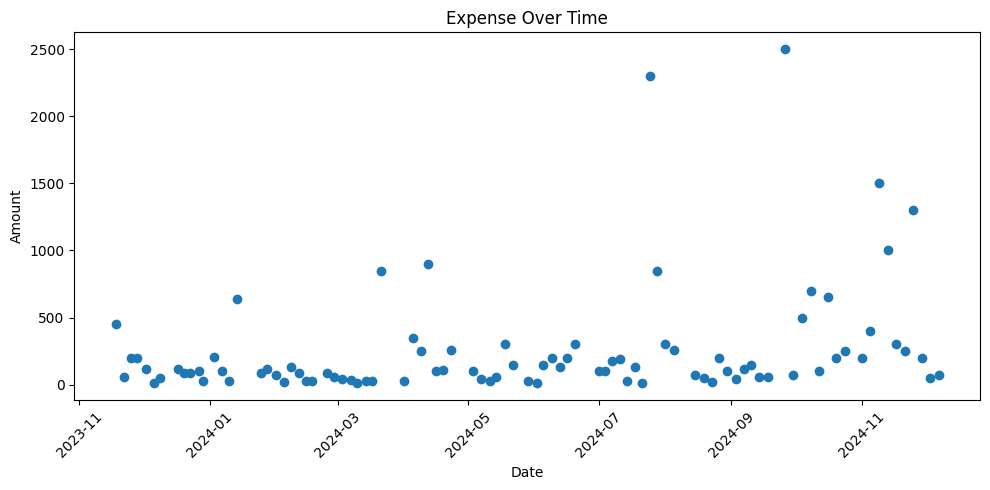

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Date' is in datetime format
new_df1['Date'] = pd.to_datetime(new_df1['Date'])

# Sort by Date
new_df1 = new_df1.sort_values('Date')

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(new_df1['Date'], new_df1['Amount'], marker='o', linestyle='-')
plt.title('Expense Over Time')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


MAIN CODE MODEL


In [ ]:
train = new_df
test=new_df1

In [ ]:
contamination = 13

In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Prepare training and testing data
X_train = train['Amount'].values.reshape(-1, 1)
X_test = test['Amount'].values.reshape(-1, 1)

X_test_anomalies = test[test['Amount'] > 600][['Amount']]
print(X_test_anomalies)

# Initialize Isolation Forest with 4% contamination
iso_forest = IsolationForest(contamination=contamination / len(X_train), random_state=42)
iso_forest.fit(X_train)

# Predict anomalies
test_preds = iso_forest.predict(X_test)

# Store predictions in test DataFrame
test['prediction'] = test_preds

# Extract anomalies from test data
anomalies = test[test['prediction'] == -1][['Date', 'Amount', 'Category']]
print("\n !Detected Anomalies:")
print(anomalies)


    Amount
15     640
31     850
35     900
59    2300
60     850
73    2500
76     700
78     650
83    1500
84    1000
87    1300

 !Detected Anomalies:
         Date  Amount        Category
0  2023-11-18     450       Education
15 2024-01-14     640        Changing
31 2024-03-21     850        Changing
33 2024-04-05     350      Stationery
35 2024-04-12     900     Accessories
59 2024-07-25    2300     Accessories
60 2024-07-28     850     Accessories
73 2024-09-26    2500  Transportation
75 2024-10-04     500            Food
76 2024-10-08     700       Education
78 2024-10-16     650       Cosmetics
82 2024-11-05     400            Food
83 2024-11-09    1500     Accessories
84 2024-11-13    1000       Cosmetics
87 2024-11-25    1300       Education


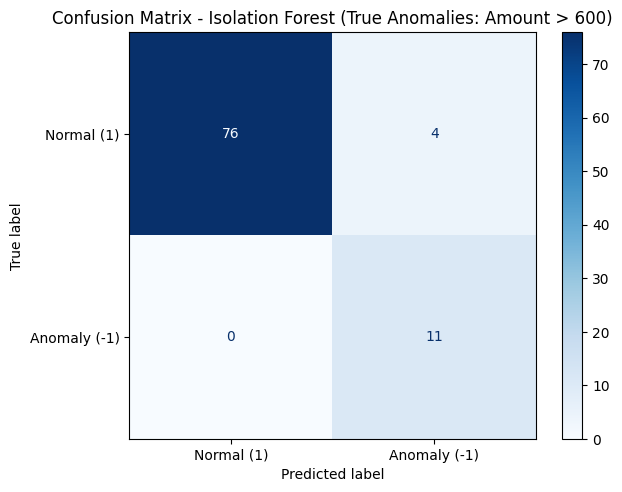


 Accuracy of the Isolation Forest Model (Based on Amount > 600): 0.96

 Classification Report (Amount > 600 as Ground Truth):
              precision    recall  f1-score   support

           1       1.00      0.95      0.97        80
          -1       0.73      1.00      0.85        11

    accuracy                           0.96        91
   macro avg       0.87      0.97      0.91        91
weighted avg       0.97      0.96      0.96        91



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Set true anomaly labels based on Amount > 600
test['is_anomaly'] = -1
test.loc[test['Amount'] <= 600, 'is_anomaly'] = 1

# Use numeric labels in confusion_matrix
cm = confusion_matrix(test['is_anomaly'], test['prediction'], labels=[1, -1])
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (1)', 'Anomaly (-1)'])
disp_cm.plot(cmap='Blues')
plt.grid(False)
plt.tight_layout()
plt.title("Confusion Matrix - Isolation Forest (True Anomalies: Amount > 600)")
plt.show()

# Accuracy
accuracy = accuracy_score(test['is_anomaly'], test['prediction'])
print(f"\n Accuracy of the Isolation Forest Model (Based on Amount > 600): {accuracy:.2f}")

# Classification Report
print("\n Classification Report (Amount > 600 as Ground Truth):")
print(classification_report(test['is_anomaly'], test['prediction'], labels=[1, -1]))


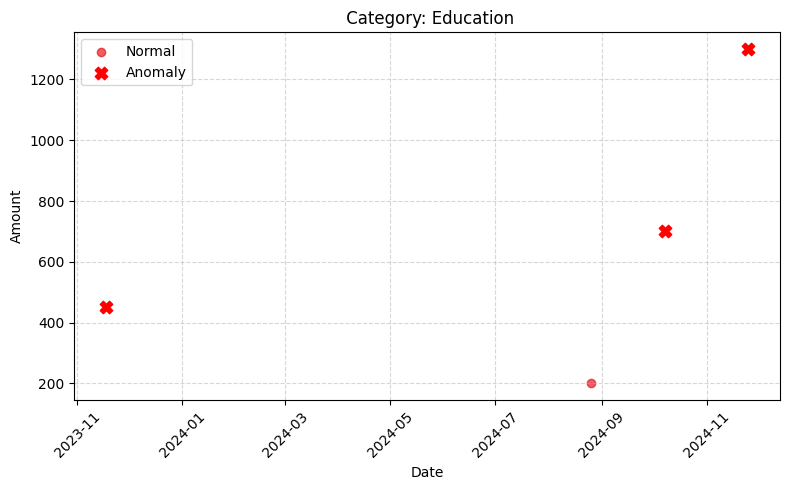

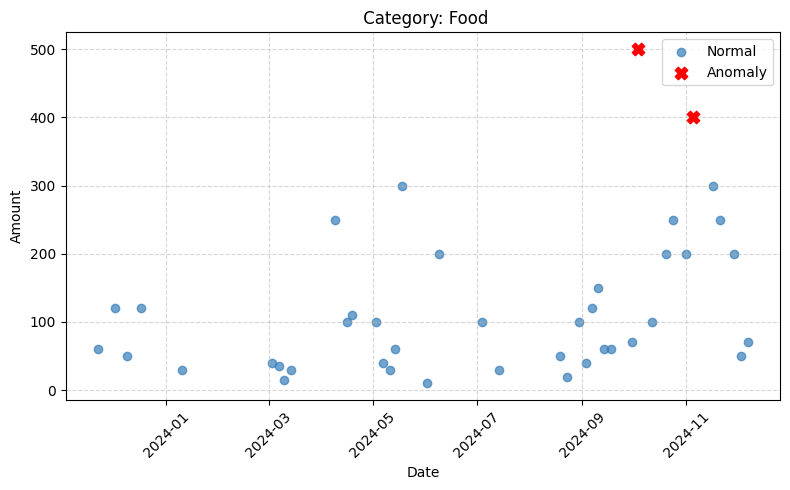

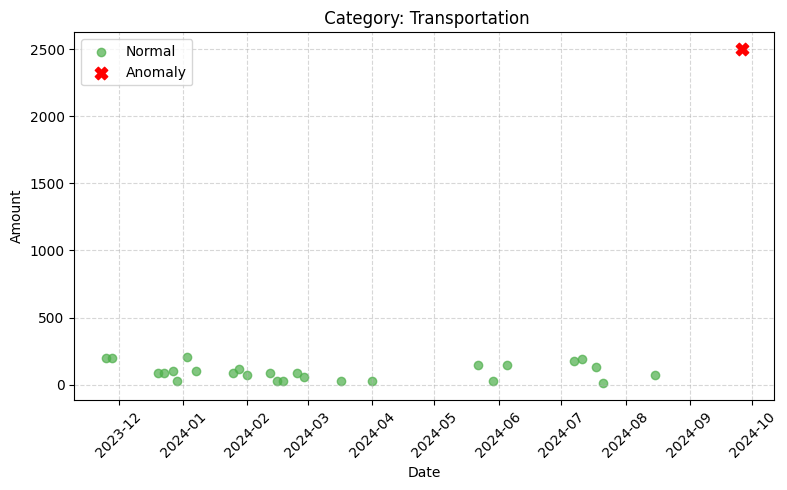

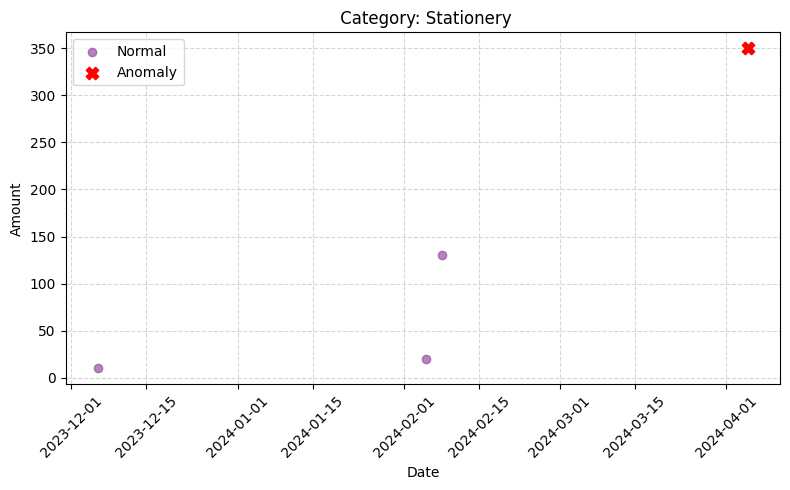

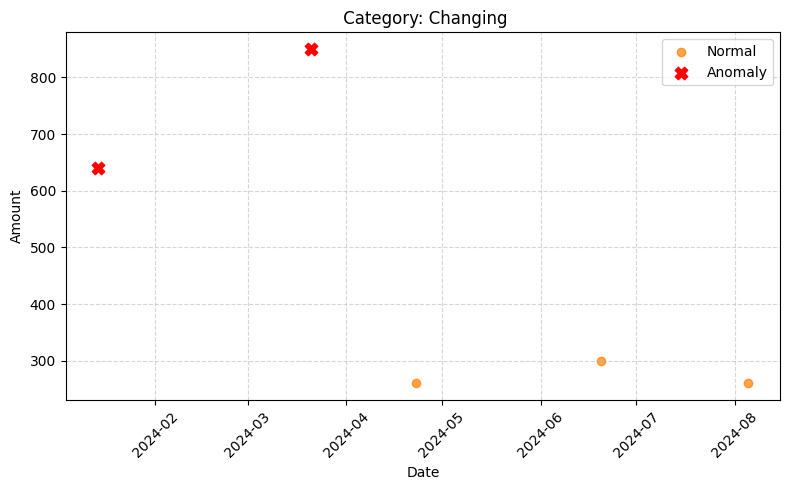

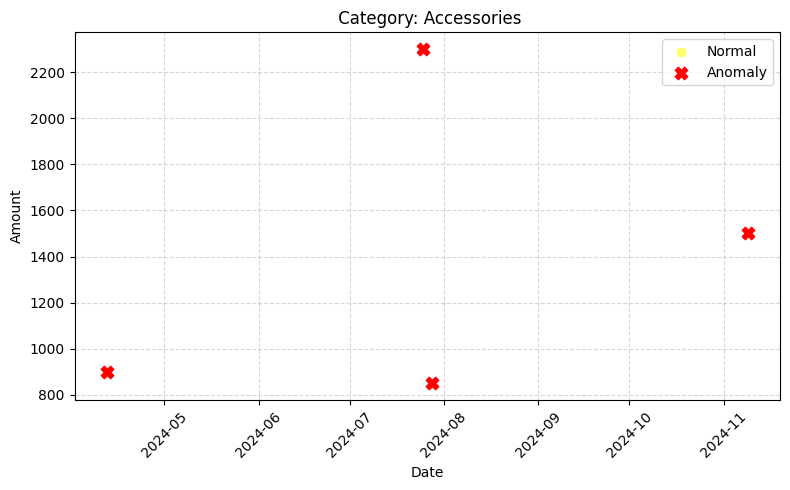

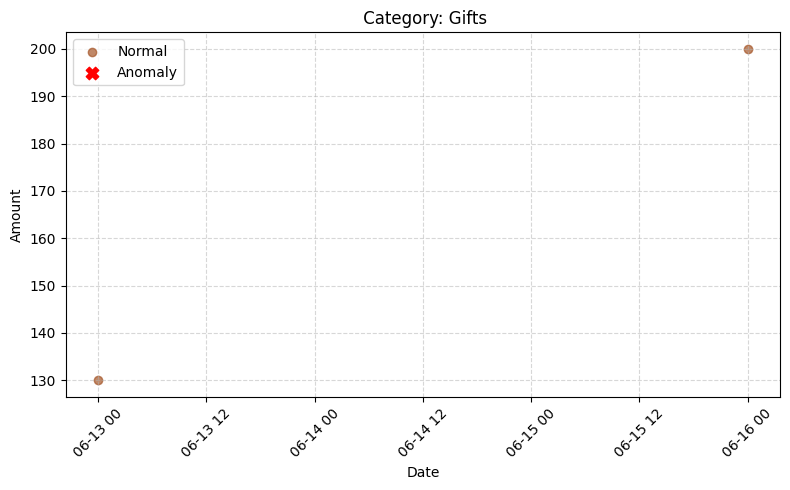

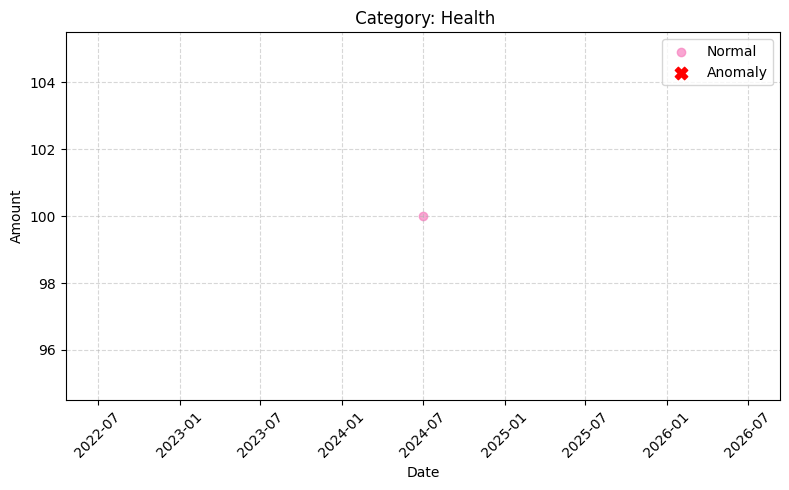

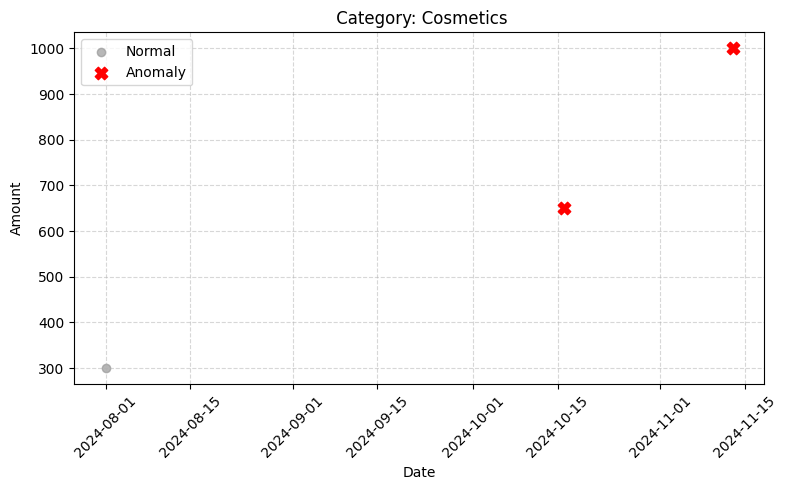

In [ ]:
import matplotlib.pyplot as plt

test['Date'] = pd.to_datetime(test['Date'])
test['prediction'] = test_preds

categories = test['Category'].unique()
colors = plt.cm.Set1.colors

for i, cat in enumerate(categories):
    cat_data = test[test['Category'] == cat]

    normal = cat_data[cat_data['prediction'] == 1]
    anomalies = cat_data[cat_data['prediction'] == -1]


    plt.figure(figsize=(8,5))
    plt.scatter(normal['Date'], normal['Amount'], label='Normal', color=colors[i % len(colors)], alpha=0.7)
    plt.scatter(anomalies['Date'], anomalies['Amount'], color='red', label='Anomaly', marker='X', s=80, zorder=5)

    plt.title(f" Category: {cat}", fontsize=12)
    plt.xlabel("Date", fontsize=10)
    plt.ylabel("Amount", fontsize=10)
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



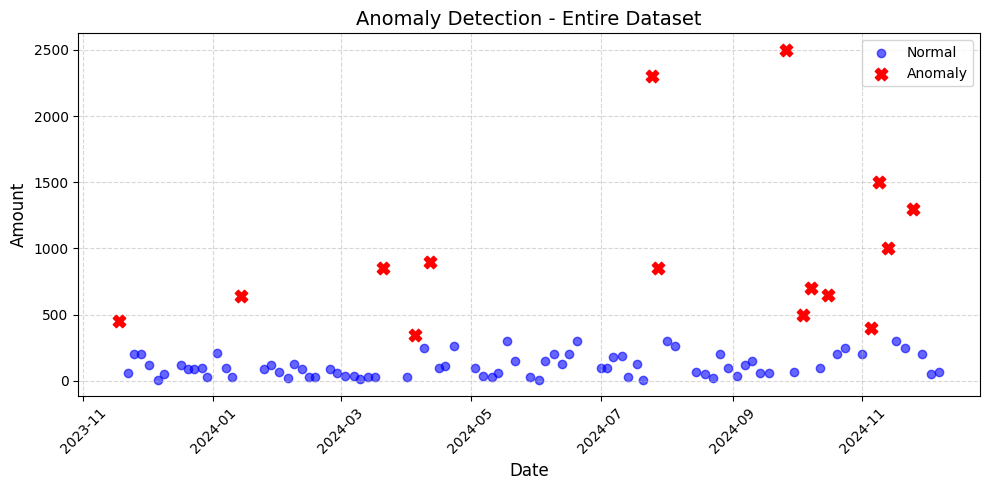

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

test['Date'] = pd.to_datetime(test['Date'])

normal_data = test[test['prediction'] == 1]
anomaly_data = test[test['prediction'] == -1]

plt.figure(figsize=(10, 5))
plt.scatter(normal_data['Date'], normal_data['Amount'], label='Normal', color='blue', alpha=0.6)
plt.scatter(anomaly_data['Date'], anomaly_data['Amount'], label='Anomaly', color='red', marker='X', s=80, zorder=5)

plt.title("Anomaly Detection - Entire Dataset", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Amount", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()